In [1]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.fftpack import fft, rfft, fftfreq
from scipy import signal


FONT_SMALL = 12
FONT_MEDIUM = 14

plt.rc('axes', titlesize=FONT_MEDIUM)
plt.rc('axes', labelsize=FONT_SMALL)
plt.rc('ytick', labelsize=FONT_SMALL)
plt.rc('legend', fontsize=FONT_MEDIUM)
plt.rc('figure', titlesize=FONT_MEDIUM)

Некоррелированный гауссов шум (белый шум):

Медиана: -0.03269
Среднеквадратичное отклонение: 10.02037


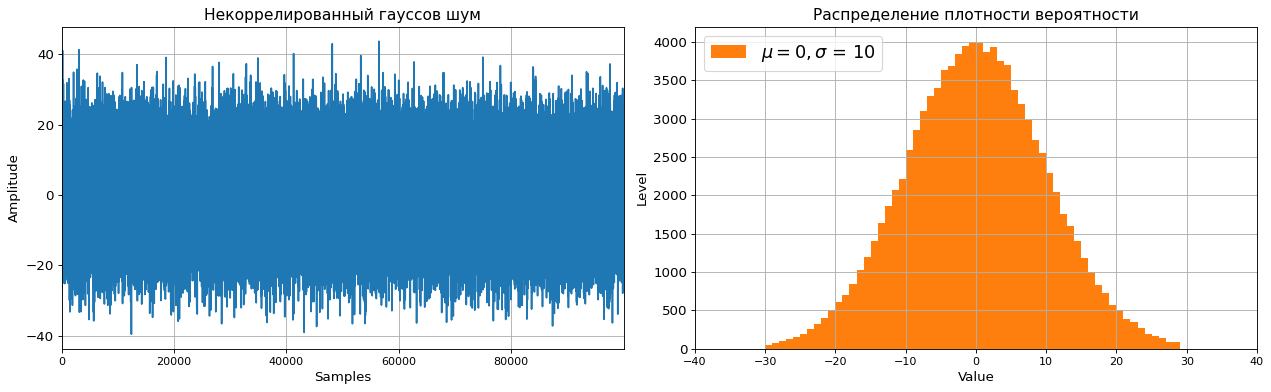

In [2]:
N = 100000

# Random signal
m, s = 0, 10
np.random.seed(2)
sig = np.random.normal(m, s, N)

# Create hist for PDF
hist, _ = np.histogram(sig, bins=list(range(0, 256)))

# Plot figure
fig = plt.figure(1, figsize=(16, 5), dpi=80)
plt.subplot(1, 2, 1)
plt.title('Некоррелированный гауссов шум')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.plot(sig, color='C0')
plt.xlim([0, N-1])
plt.grid()

plt.subplot(1, 2, 2)
plt.title('Распределение плотности вероятности')
plt.xlabel('Value')
plt.ylabel('Level')
plt.xlim([-4*s, 4*s])
plt.hist(sig, bins=list(range(-s*3, s*3)), color='C1', label=r'$\mu = %d, \sigma$ = %d' % (m, s))
plt.grid()
plt.legend(loc='upper left', fontsize=16)
plt.tight_layout()

print('Медиана:', np.mean(sig).round(5))
print('Среднеквадратичное отклонение:', np.std(sig).round(5))

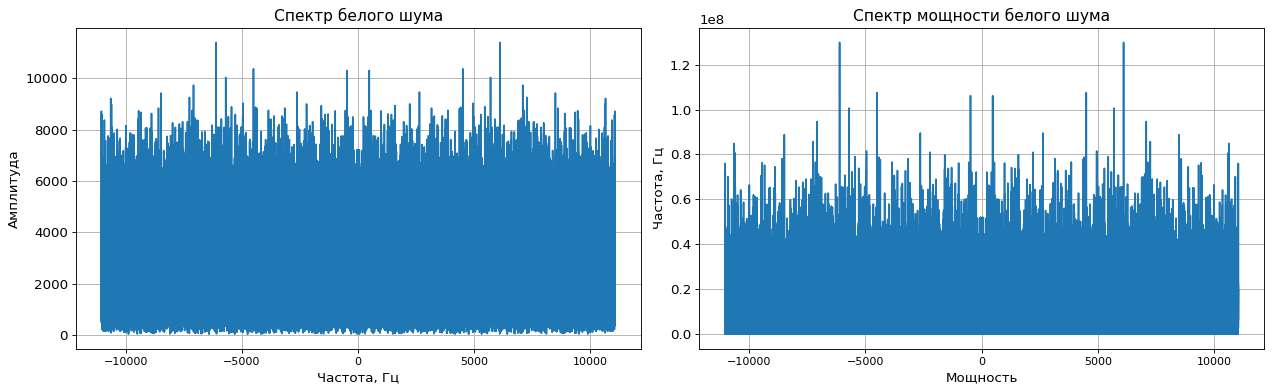

In [3]:
fs = 22100

T = 1.0 / fs
N = len(sig)

# спектр сигнала
yf = fft(sig)
xf = fftfreq(N, T)

yf_power = yf**2


fig = plt.figure(1, figsize=(16, 5), dpi=80)
plt.subplot(1, 2, 1)
plt.title('Спектр белого шума')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.plot(xf, np.abs(yf), color='C0')
plt.grid()

plt.subplot(1, 2, 2)
plt.title('Спектр мощности белого шума')
plt.xlabel('Мощность')
plt.ylabel('Частота, Гц')
plt.plot(xf, np.abs(yf_power), color='C0')
plt.grid()
plt.tight_layout()

In [4]:
# Автокорреляция
def auto_corr(x):
    res = np.correlate(x, x, mode='same')
    return res / np.max(res)

Поскольку частотные значения распределены равномерно, автокорреляционная функция (АКФ) белого шума в идеале стремится к дельта-функции.

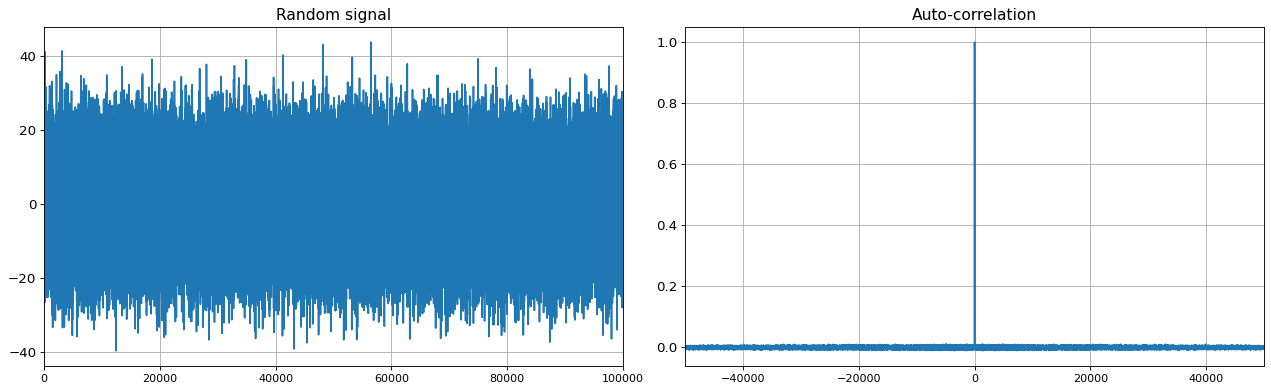

In [5]:
cfx = auto_corr(sig)

plt.figure(figsize=(16, 5), dpi=80)
plt.subplot(1, 2, 1)
plt.title('Random signal')
plt.plot(sig)
plt.xlim([0, sig.size])
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Auto-correlation')
plt.plot(np.linspace(-N//2, N//2, N), cfx)
plt.xlim([-N//2, N//2])
plt.grid(True)
plt.tight_layout()

In [6]:
from IPython.display import Audio

Audio(sig, rate=fs)

Броуновский шум (красный шум)

In [7]:
def brownian_noise(length, scale=1.0):
    """Генерация 1D броуновского шума через Фурье-преобразование"""
    # Генерируем частоты (исключая нулевую)
    frequencies = np.fft.fftfreq(length)
    frequencies[0] = 1e-10  # избегаем деления на 0

    # Создаем спектр мощности (1/f^2)
    power_spectrum = scale / (frequencies ** 2)

    # Генерируем случайные фазы
    phases = np.random.uniform(0, 2*np.pi, length)

    # Собираем комплексный спектр
    complex_spectrum = np.sqrt(power_spectrum) * np.exp(1j * phases)

    # Обратное Фурье-преобразование
    noise = np.fft.ifft(complex_spectrum)

    # Нормализуем и возвращаем действительную часть
    return np.real(noise) / np.std(noise)

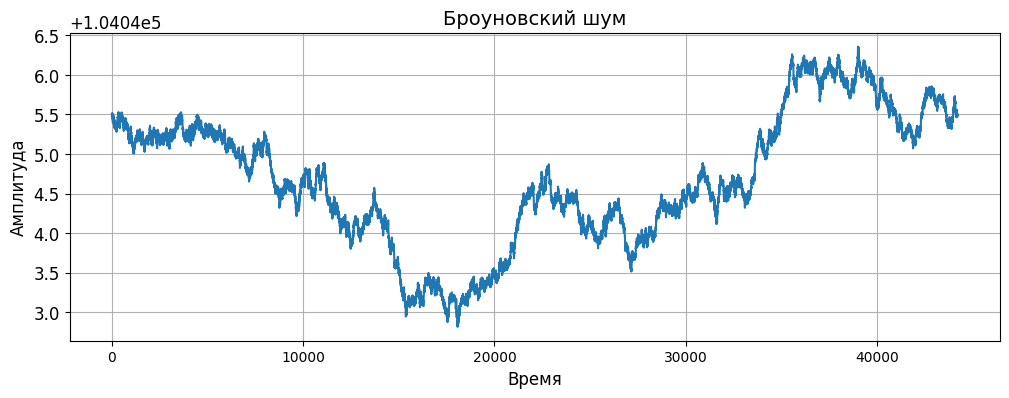

In [8]:
# Параметры
length = fs * 2  # Длина сигнала
scale = 5.0    # Масштаб шума

brown_noise = brownian_noise(length, scale)
plt.figure(figsize=(12, 4))
plt.plot(brown_noise)
plt.title(f"Броуновский шум")
plt.xlabel("Время")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

In [9]:
from IPython.display import Audio

Audio(brown_noise, rate=fs)

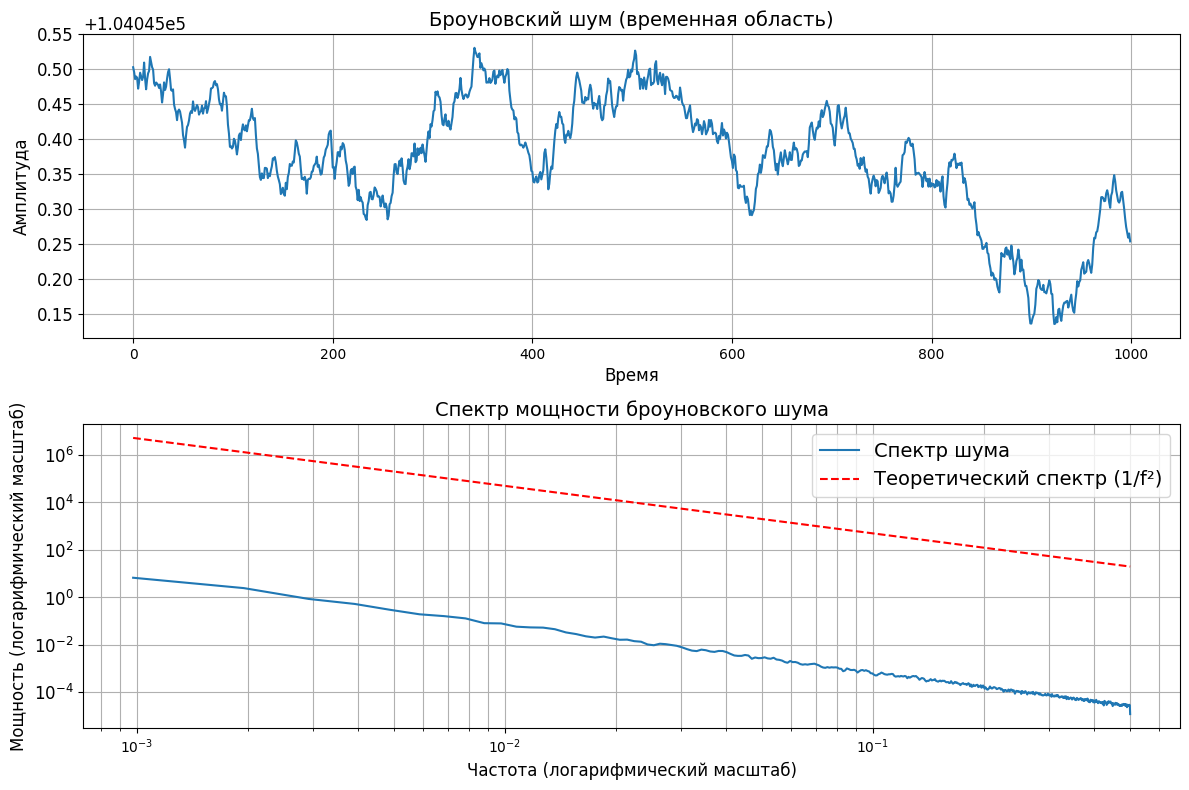

In [10]:
# Вычисление спектра мощности
freqs, psd = signal.welch(brown_noise, fs=1.0, nperseg=1024)

# Построение графиков
plt.figure(figsize=(12, 8))

# Временной ряд
plt.subplot(2, 1, 1)
plt.plot(brown_noise[:1000])  # Показываем только первые 1000 точек
plt.title("Броуновский шум (временная область)")
plt.xlabel("Время")
plt.ylabel("Амплитуда")
plt.grid(True)

# Спектр мощности в логарифмическом масштабе
plt.subplot(2, 1, 2)
plt.loglog(freqs[freqs > 0], psd[freqs > 0], label='Спектр шума')
plt.loglog(freqs[freqs > 0], scale/(freqs[freqs > 0]**2), 'r--',
          label='Теоретический спектр (1/f²)')
plt.title("Спектр мощности броуновского шума")
plt.xlabel("Частота (логарифмический масштаб)")
plt.ylabel("Мощность (логарифмический масштаб)")
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

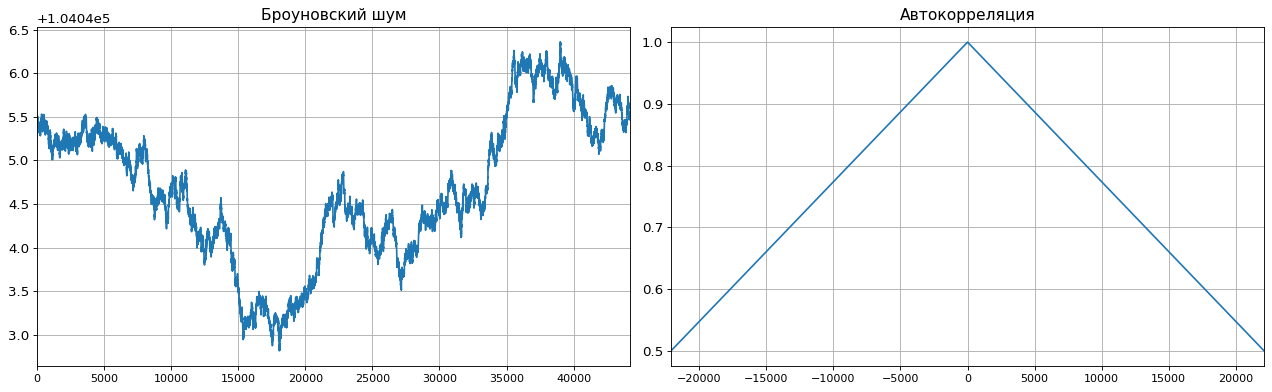

In [11]:
cfx = auto_corr(brown_noise)
N = len(brown_noise)

plt.figure(figsize=(16, 5), dpi=80)
plt.subplot(1, 2, 1)
plt.title('Броуновский шум')
plt.plot(brown_noise)
plt.xlim([0, brown_noise.size])
plt.grid(True)

plt.subplot(1, 2, 2)
plt.title('Автокорреляция')
plt.plot(np.linspace(-N//2, N//2, N), cfx)
plt.xlim([-N//2, N//2])
plt.grid(True)
plt.tight_layout()

Розовый шум

In [12]:
def pink_noise(length, scale=1.0):
    """Генерация 1D розового шума через Фурье-преобразование"""
    frequencies = np.fft.fftfreq(length)
    frequencies[0] = 1e-10  # избегаем деления на 0

    # Спектр мощности для розового шума (1/f)
    power_spectrum = scale / np.abs(frequencies)

    # Случайные фазы
    phases = np.random.uniform(0, 2*np.pi, length)

    # Собираем комплексный спектр
    complex_spectrum = np.sqrt(power_spectrum) * np.exp(1j * phases)

    # Обратное Фурье-преобразование
    noise = np.fft.ifft(complex_spectrum)

    # Нормализуем и возвращаем действительную часть
    return np.real(noise) / np.std(noise)

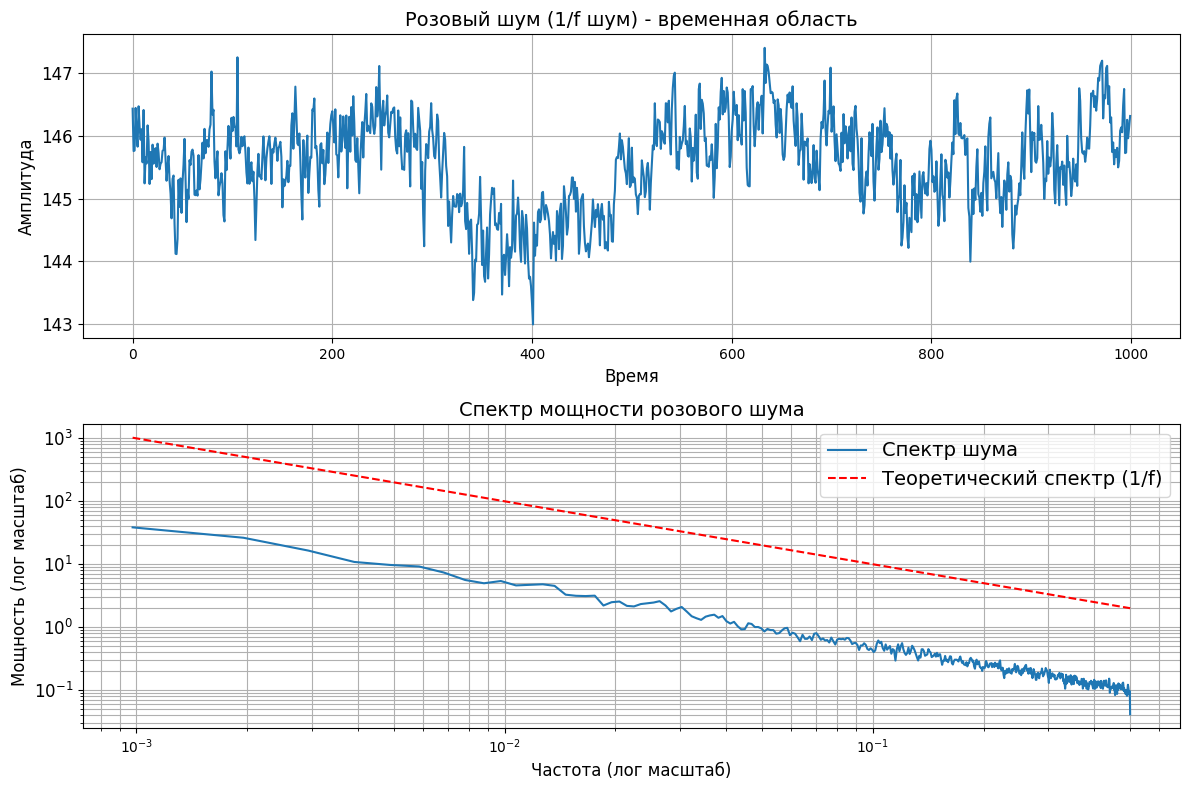

In [13]:
# Параметры
length = 22100  # Длина сигнала
scale = 1.0

# Генерация шума
pink_noise = pink_noise(length, scale)

# Вычисление спектра мощности
freqs, psd = signal.welch(pink_noise, fs=1.0, nperseg=1024)

# Построение графиков
plt.figure(figsize=(12, 8))

# Временной ряд
plt.subplot(2, 1, 1)
plt.plot(pink_noise[:1000])  # Показываем только первые 1000 точек
plt.title("Розовый шум (1/f шум) - временная область")
plt.xlabel("Время")
plt.ylabel("Амплитуда")
plt.grid(True)

# Спектр мощности в логарифмическом масштабе
plt.subplot(2, 1, 2)
plt.loglog(freqs[freqs > 0], psd[freqs > 0], label='Спектр шума')
plt.loglog(freqs[freqs > 0], scale/freqs[freqs > 0], 'r--',
          label='Теоретический спектр (1/f)')
plt.title("Спектр мощности розового шума")
plt.xlabel("Частота (лог масштаб)")
plt.ylabel("Мощность (лог масштаб)")
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

In [22]:
Audio(pink_noise, rate=fs / 2)

Зеленый шум

In [15]:
def generate_green_noise(length, fs, center_freq, bandwidth):
    # Генерируем белый шум
    white_noise = np.random.randn(length)

    # Частоты для FFT
    freqs = np.fft.fftfreq(length, d=1/fs)

    # Создаем полосовой фильтр (гауссово окно)
    filter = np.exp(-(freqs - center_freq)**2 / (2 * (bandwidth/2)**2))
    filter += np.exp(-(freqs + center_freq)**2 / (2 * (bandwidth/2)**2))  # Для симметрии

    # Применяем фильтр
    fft_white = np.fft.fft(white_noise)
    fft_green = fft_white * filter
    green_noise = np.fft.ifft(fft_green)

    return np.real(green_noise) / np.std(green_noise)

In [16]:
length = 44200  # Длина сигнала
fs = 22100      # Частота дискретизации (аудиостандарт)
center_freq = 1500  # Центральная частота (Гц)
bandwidth = 1000     # Ширина полосы (Гц)

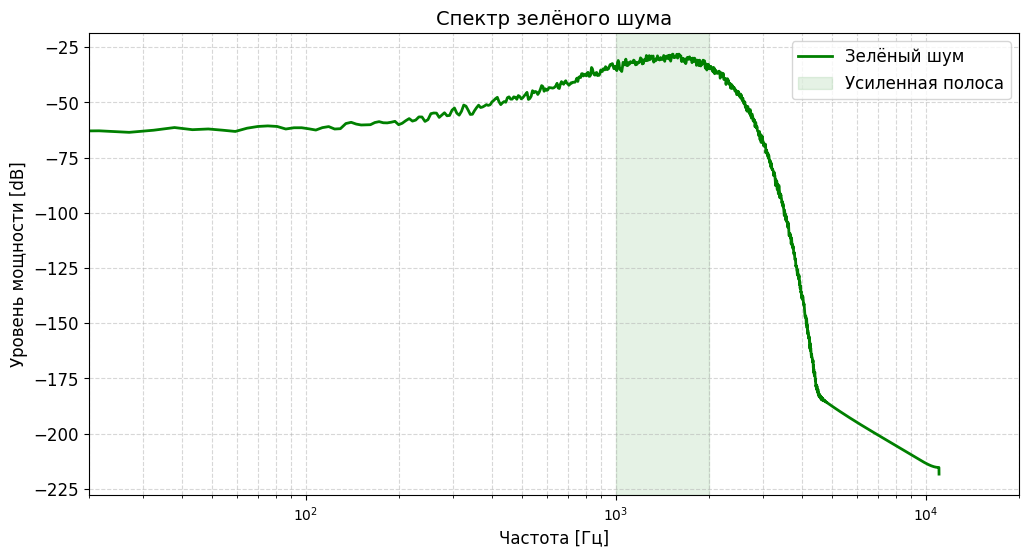

In [17]:
# Генерация
green_noise = generate_green_noise(length, fs, center_freq, bandwidth)

# Анализ спектра
freqs, psd = signal.welch(green_noise, fs=fs, nperseg=4096)

# Визуализация
plt.figure(figsize=(12, 6))
plt.semilogx(freqs, 10*np.log10(psd), 'g-', label='Зелёный шум', linewidth=2)
plt.axvspan(center_freq-bandwidth/2, center_freq+bandwidth/2, color='green', alpha=0.1, label='Усиленная полоса')
plt.title('Спектр зелёного шума', fontsize=14)
plt.xlabel('Частота [Гц]', fontsize=12)
plt.ylabel('Уровень мощности [dB]', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlim(20, 20000)
plt.legend(fontsize=12)
plt.show()

In [18]:
Audio(green_noise, rate=fs / 2)

In [ ]:
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/ata0003.wav
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/ata0003.seg_B1
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/s.wav
!wget "https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/s'.wav"
!wget "https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/f'.wav"
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/linear_models/files/sh.wav

In [33]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import welch

def get_psd(audio_path):
  y, sr = librosa.load(audio_path)

  frequencies, psd = welch(y, sr, nperseg=1024)
  psd_db = 10 * np.log10(psd)

  return frequencies, psd_db

Text(0.5, 1.0, "s'")

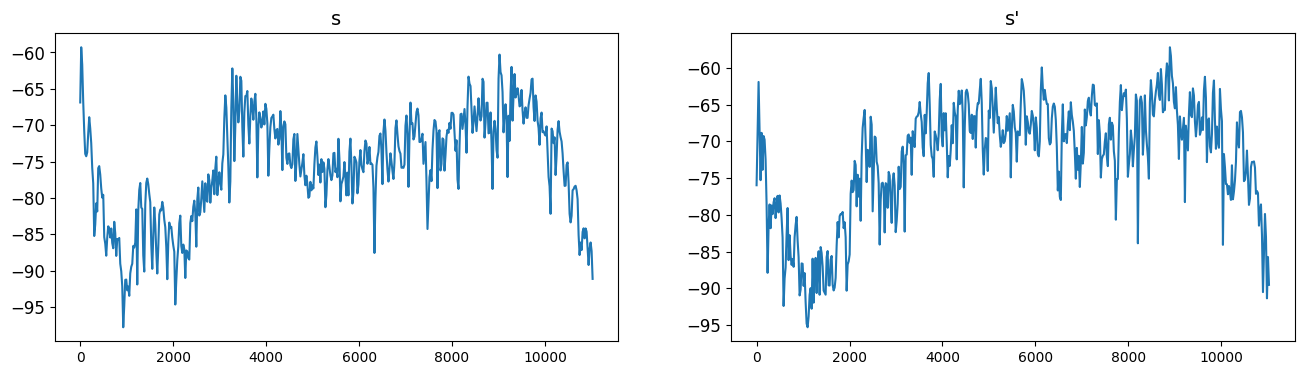

In [36]:
plt.figure(figsize=(16, 4))

frequencies, psd = get_psd("s.wav")
frequencies_, psd_ = get_psd("s'.wav")

plt.subplot(1, 2, 1)
plt.plot(frequencies, psd)
plt.title('s')

plt.subplot(1, 2, 2)
plt.plot(frequencies_, psd_)
plt.title("s'")

Text(0.5, 1.0, "f'")

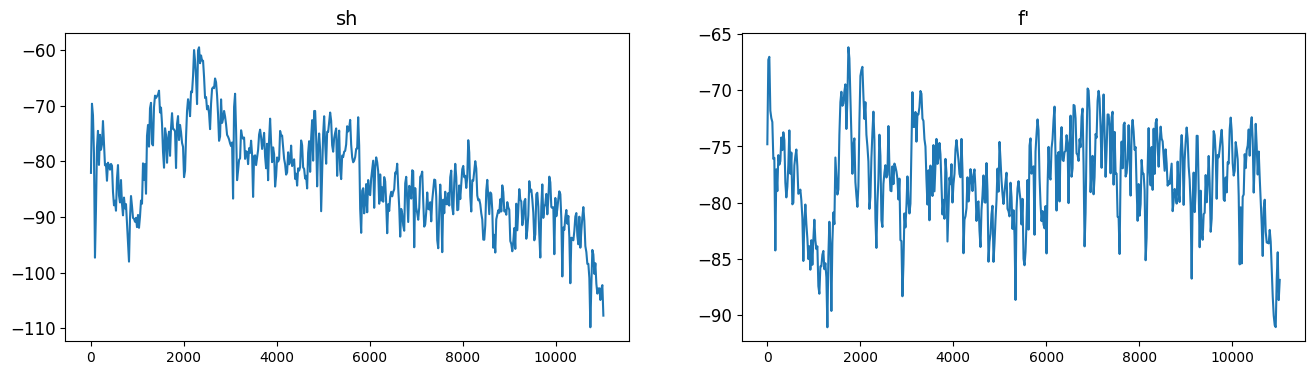

In [38]:
plt.figure(figsize=(16, 4))

frequencies, psd = get_psd("sh.wav")
frequencies_, psd_ = get_psd("f'.wav")

plt.subplot(1, 2, 1)
plt.plot(frequencies, psd)
plt.title('sh')

plt.subplot(1, 2, 2)
plt.plot(frequencies_, psd_)
plt.title("f'")

Задание.

Наложите разные виды шумов на запись ata0003.wav. Оцените, какие шумы лучше маскируют различные классы звуков.